# EDA inicial e baseline NLP para classificacao de textos hospitalares

Este notebook realiza uma analise exploratoria inicial do dataset
[Medical Abstracts TC Corpus](https://www.kaggle.com/datasets/saharalaa/medical-abstracts-tc-corpus?resource=download)
e testa baselines simples para classificacao multiclasse de textos medicos.

O objetivo aqui e entender a estrutura e qualidade dos dados, levantar necessidades
de preprocessamento textual e propor uma arquitetura teorica inicial para um MVP.
Esta etapa e exploratoria: ela nao representa ainda o pipeline final de producao,
nem validacao clinica do modelo.

## Definicao do problema

O problema sera tratado como **classificacao multiclasse**: cada resumo medico
possui uma unica doenca/classe associada. O classificador recebe um texto e deve
retornar uma das classes existentes no dataset.

Em contexto hospitalar, a leitura das metricas deve dar atencao especial ao
**recall por classe**, pois falsos negativos em classes relevantes podem atrasar
a priorizacao de casos que merecem revisao humana.

## Imports de bibliotecas

In [1]:
# Manipulacao de dados
from collections import Counter
from html import escape
import re
import unicodedata
from pathlib import Path

import numpy as np
import pandas as pd

# Visualizacao
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# Processamento de texto
import nltk
from nltk.corpus import stopwords
import spacy
from unidecode import unidecode

# Modelagem
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS, TfidfVectorizer
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

# Metricas
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
)

# Utilidades
import sklearn

sns.set_theme(style="whitegrid")
pd.set_option("display.max_colwidth", 120)

## Configuracao do notebook

In [2]:
RANDOM_STATE = 42
WORKING_SAMPLE_SIZE = 6000
TEXT_COLUMN = "medical_abstract"
TARGET_ID_COLUMN = "condition_label"
TARGET_COLUMN = "condition_name"
SPACY_MODEL = "en_core_web_sm"

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data" / "raw").exists() and (PROJECT_ROOT.parent / "data" / "raw").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "data" / "raw"
REPORT_DIR = PROJECT_ROOT / "reports"
FIGURE_DIR = REPORT_DIR / "figures"
REPORT_PATH = REPORT_DIR / "eda_nlp_hospital_baseline.html"

REPORT_DIR.mkdir(exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

TRAIN_PATH = DATA_DIR / "medical_tc_train.csv"
TEST_PATH = DATA_DIR / "medical_tc_test.csv"
LABELS_PATH = DATA_DIR / "medical_tc_labels.csv"

print(f"Projeto: {PROJECT_ROOT}")
print(f"Dados: {DATA_DIR}")
print(f"Relatorio HTML: {REPORT_PATH}")

Projeto: C:\Users\jooar\ds\portfolio\ml3-f3-tech-challenge
Dados: C:\Users\jooar\ds\portfolio\ml3-f3-tech-challenge\data\raw
Relatorio HTML: C:\Users\jooar\ds\portfolio\ml3-f3-tech-challenge\reports\eda_nlp_hospital_baseline.html


## Importacao dos dados

In [3]:
required_files = [TRAIN_PATH, TEST_PATH, LABELS_PATH]
missing_files = [path for path in required_files if not path.exists()]
if missing_files:
    raise FileNotFoundError(
        "Arquivos esperados nao encontrados: "
        + ", ".join(str(path) for path in missing_files)
        + ". Baixe o dataset do Kaggle e mantenha os CSVs em data/raw."
    )

train_raw = pd.read_csv(TRAIN_PATH)
test_raw = pd.read_csv(TEST_PATH)
labels = pd.read_csv(LABELS_PATH)

df = pd.concat(
    [
        train_raw.assign(source_split="kaggle_train"),
        test_raw.assign(source_split="kaggle_test"),
    ],
    ignore_index=True,
)
df = df.merge(labels, on=TARGET_ID_COLUMN, how="left")

display(df.head())
print(f"Shape treino Kaggle: {train_raw.shape}")
print(f"Shape teste Kaggle: {test_raw.shape}")
print(f"Shape consolidado: {df.shape}")
print(f"Colunas disponiveis: {list(df.columns)}")
print(f"Coluna de texto: {TEXT_COLUMN}")
print(f"Coluna target: {TARGET_COLUMN}")

,condition_label,medical_abstract,source_split,condition_name
0,5,Tissue changes around loose prostheses. A canine model to investigate the effects of an antiinflammatory agent. The ...,kaggle_train,general pathological conditions
1,1,Neuropeptide Y and neuron-specific enolase levels in benign and malignant pheochromocytomas. Neuron-specific enolase...,kaggle_train,neoplasms
2,2,"Sexually transmitted diseases of the colon, rectum, and anus. The challenge of the nineties. During the past two dec...",kaggle_train,digestive system diseases
3,1,Lipolytic factors associated with murine and human cancer cachexia. We have identified a lipolytic factor in extract...,kaggle_train,neoplasms
4,3,"Does carotid restenosis predict an increased risk of late symptoms, stroke, or death? The identification of carotid ...",kaggle_train,nervous system diseases


Shape treino Kaggle: (11550, 2)
Shape teste Kaggle: (2888, 2)
Shape consolidado: (14438, 4)
Colunas disponiveis: ['condition_label', 'medical_abstract', 'source_split', 'condition_name']
Coluna de texto: medical_abstract
Coluna target: condition_name


## Entendimento inicial da base

In [4]:
df["text_original"] = df[TEXT_COLUMN].astype("string").fillna("")
df["text_length_chars"] = df["text_original"].str.len()
df["text_length_words"] = df["text_original"].str.split().str.len()

class_distribution = (
    df[TARGET_COLUMN]
    .value_counts(dropna=False)
    .rename_axis("classe")
    .reset_index(name="registros")
)
class_distribution["proporcao"] = class_distribution["registros"] / len(df)

print(f"Quantidade de registros: {len(df):,}")
print(f"Quantidade de classes: {df[TARGET_COLUMN].nunique(dropna=True)}")
display(class_distribution)
display(df[["text_length_chars", "text_length_words"]].describe().round(2))

safe_examples = (
    df.sample(min(5, len(df)), random_state=RANDOM_STATE)
    [[TARGET_COLUMN, "text_original"]]
    .assign(text_original=lambda data: data["text_original"].str.slice(0, 260) + "...")
)
display(safe_examples)

Quantidade de registros: 14,438


Quantidade de classes: 5


,classe,registros,proporcao
0,general pathological conditions,4805,0.332802
1,neoplasms,3163,0.219075
2,cardiovascular diseases,3051,0.211317
3,nervous system diseases,1925,0.133329
4,digestive system diseases,1494,0.103477


,text_length_chars,text_length_words
count,14438.0,14438.00
mean,1230.67,179.94
std,507.35,76.55
min,170.0,24.00
25%,850.0,122.00
50%,1210.0,176.00
75%,1589.0,235.00
max,3999.0,596.00


,condition_name,text_original
4417,cardiovascular diseases,A manifesting carrier of Duchenne muscular dystrophy with severe myocardial symptoms. A 42-year-old so-called manife...
907,cardiovascular diseases,Transesophageal Doppler color flow mapping assessment of atrial septal defect. Transesophageal Doppler color flow im...
2859,cardiovascular diseases,Outcomes of direct coronary angioplasty for acute myocardial infarction in candidates and non-candidates for thrombo...
5836,cardiovascular diseases,Salvage from cardiogenic shock by atherectomy after failed emergency coronary artery angioplasty. In this case repor...
2715,neoplasms,Leukaemia complicating treatment for Hodgkin's disease: the experience of the British National Lymphoma Investigatio...


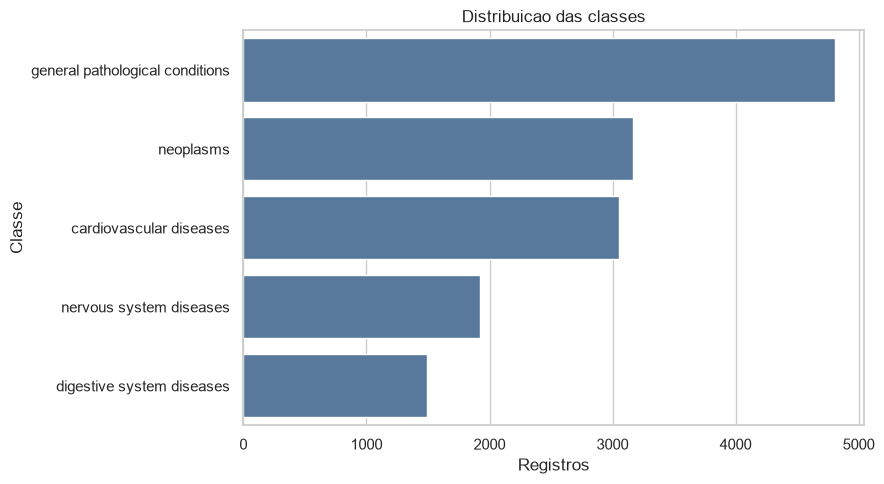

In [5]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=class_distribution, x="registros", y="classe", ax=ax, color="#4C78A8")
ax.set_title("Distribuicao das classes")
ax.set_xlabel("Registros")
ax.set_ylabel("Classe")
plt.tight_layout()
class_plot_path = FIGURE_DIR / "class_distribution.png"
fig.savefig(class_plot_path, dpi=140, bbox_inches="tight")
plt.show()

## Sanity check

In [6]:
sanity_report = pd.DataFrame(
    {
        "checagem": [
            "linhas",
            "colunas",
            "textos nulos",
            "targets nulos",
            "textos vazios",
            "textos muito curtos (< 20 caracteres)",
            "duplicidades totais",
            "duplicidades por texto",
            "duplicidades por texto e classe",
            "classes sem nome apos merge",
        ],
        "valor": [
            len(df),
            df.shape[1],
            int(df[TEXT_COLUMN].isna().sum()),
            int(df[TARGET_COLUMN].isna().sum()),
            int(df["text_original"].str.strip().eq("").sum()),
            int(df["text_length_chars"].lt(20).sum()),
            int(df.duplicated().sum()),
            int(df.duplicated(subset=["text_original"]).sum()),
            int(df.duplicated(subset=["text_original", TARGET_COLUMN]).sum()),
            int(df[TARGET_COLUMN].isna().sum()),
        ],
    }
)
display(sanity_report)

print("Observacao: esta secao apenas diagnostica problemas; nenhum tratamento e aplicado aqui.")

,checagem,valor
0,linhas,14438
1,colunas,7
2,textos nulos,0
3,targets nulos,0
4,textos vazios,0
5,textos muito curtos (< 20 caracteres),0
6,duplicidades totais,0
7,duplicidades por texto,3211
8,duplicidades por texto e classe,0
9,classes sem nome apos merge,0


Observacao: esta secao apenas diagnostica problemas; nenhum tratamento e aplicado aqui.


## Funcoes auxiliares

In [7]:
def normalize_text(text: str) -> str:
    """Normalize unicode, lowercase and collapse whitespace.

    Parameters
    ----------
    text:
        Raw input text.

    Returns
    -------
    str
        Text with normalized accents, lowercase letters and single spaces.
    """
    if pd.isna(text):
        return ""
    text = str(text).lower().strip()
    text = unidecode(unicodedata.normalize("NFKD", text))
    return re.sub(r"\s+", " ", text)


def load_stopwords(language: str = "english") -> set[str]:
    """Load NLTK stopwords with a deterministic fallback.

    Parameters
    ----------
    language:
        NLTK stopword language.

    Returns
    -------
    set[str]
        Stopword set used by the text preprocessing step.
    """
    try:
        return set(stopwords.words(language))
    except LookupError:
        try:
            nltk.download("stopwords", quiet=True)
            return set(stopwords.words(language))
        except Exception:
            return set(ENGLISH_STOP_WORDS)


def load_spacy_pipeline(model_name: str = SPACY_MODEL):
    """Load the spaCy model used for lemmatization.

    Parameters
    ----------
    model_name:
        Installed spaCy language model name.

    Returns
    -------
    tuple
        Loaded spaCy object and a human-readable description of the model.
    """
    try:
        nlp = spacy.load(model_name, disable=["ner", "parser"])
        return nlp, model_name
    except OSError:
        nlp = spacy.blank("en")
        return nlp, "spacy.blank('en') - fallback sem lematizador estatistico"


def clean_text(text: str, stop_words: set[str], nlp, remove_numbers: bool = False) -> str:
    """Clean, tokenize, remove stopwords and lemmatize one text.

    Parameters
    ----------
    text:
        Raw input text.
    stop_words:
        Stopword set.
    nlp:
        spaCy pipeline.
    remove_numbers:
        Whether numeric tokens should be removed.

    Returns
    -------
    str
        Preprocessed text reconstructed from useful tokens.
    """
    text = normalize_text(text)
    if remove_numbers:
        text = re.sub(r"\d+", " ", text)
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    doc = nlp(text)
    tokens = []
    for token in doc:
        lemma = token.lemma_.strip() if token.lemma_ else token.text
        lemma = lemma.lower().strip()
        if not lemma or lemma in stop_words or len(lemma) <= 1:
            continue
        if remove_numbers and lemma.isnumeric():
            continue
        tokens.append(lemma)
    return " ".join(tokens)


def make_stratified_sample(data: pd.DataFrame, n_rows: int, target_col: str) -> pd.DataFrame:
    """Return a stratified sample when the dataset is larger than n_rows.

    Parameters
    ----------
    data:
        Input dataframe.
    n_rows:
        Maximum desired rows.
    target_col:
        Class column used for stratification.

    Returns
    -------
    pd.DataFrame
        Full dataset or stratified sample.
    """
    if n_rows is None or len(data) <= n_rows:
        return data.copy()
    _, sample = train_test_split(
        data,
        test_size=n_rows,
        stratify=data[target_col],
        random_state=RANDOM_STATE,
    )
    return sample.reset_index(drop=True)


def plot_top_terms(series: pd.Series, title: str, output_path: Path, top_n: int = 20) -> pd.DataFrame:
    """Plot and return the most frequent tokens.

    Parameters
    ----------
    series:
        Text series already preprocessed.
    title:
        Plot title.
    output_path:
        Image path to save the plot.
    top_n:
        Number of terms to show.

    Returns
    -------
    pd.DataFrame
        Term-frequency table.
    """
    counter = Counter(" ".join(series.dropna()).split())
    top_terms = pd.DataFrame(counter.most_common(top_n), columns=["termo", "frequencia"])
    fig, ax = plt.subplots(figsize=(9, 6))
    sns.barplot(data=top_terms, x="frequencia", y="termo", color="#59A14F", ax=ax)
    ax.set_title(title)
    ax.set_xlabel("Frequencia")
    ax.set_ylabel("Termo")
    plt.tight_layout()
    fig.savefig(output_path, dpi=140, bbox_inches="tight")
    plt.show()
    return top_terms


def generate_wordcloud(texts: pd.Series, title: str, output_path: Path) -> None:
    """Generate and save a wordcloud for a text collection.

    Parameters
    ----------
    texts:
        Preprocessed text series.
    title:
        Figure title.
    output_path:
        Image path to save the wordcloud.
    """
    joined_text = " ".join(texts.dropna().astype(str))
    if not joined_text.strip():
        print(f"Sem texto suficiente para wordcloud: {title}")
        return
    cloud = WordCloud(width=1000, height=500, background_color="white", colormap="viridis").generate(joined_text)
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.imshow(cloud, interpolation="bilinear")
    ax.axis("off")
    ax.set_title(title)
    fig.savefig(output_path, dpi=140, bbox_inches="tight")
    plt.show()


def evaluate_model(model_name: str, y_true: pd.Series, y_pred: np.ndarray) -> tuple[dict, pd.DataFrame]:
    """Calculate aggregate and per-class classification metrics.

    Parameters
    ----------
    model_name:
        Name used in the comparative table.
    y_true:
        True labels.
    y_pred:
        Predicted labels.

    Returns
    -------
    tuple[dict, pd.DataFrame]
        Aggregate metric row and detailed class report.
    """
    weighted = precision_recall_fscore_support(y_true, y_pred, average="weighted", zero_division=0)
    macro = precision_recall_fscore_support(y_true, y_pred, average="macro", zero_division=0)
    report = pd.DataFrame(classification_report(y_true, y_pred, zero_division=0, output_dict=True)).T
    class_report = report.loc[[label for label in sorted(y_true.unique()) if label in report.index]].copy()
    minority_classes = y_true.value_counts().tail(2).index.tolist()
    minority_recall = class_report.loc[class_report.index.intersection(minority_classes), "recall"].mean()
    row = {
        "modelo": model_name,
        "weighted_precision": weighted[0],
        "weighted_recall": weighted[1],
        "weighted_f1": weighted[2],
        "macro_precision": macro[0],
        "macro_recall": macro[1],
        "macro_f1": macro[2],
        "recall_medio_classes_minoritarias": minority_recall,
        "observacao_classes_minoritarias": (
            "acompanhar de perto; metrica ponderada pode mascarar desempenho"
            if minority_recall < weighted[1]
            else "recall minoritario proximo da media ponderada no split avaliado"
        ),
    }
    return row, class_report


def plot_confusion(y_true: pd.Series, y_pred: np.ndarray, title: str, output_path: Path) -> None:
    """Plot and save a confusion matrix.

    Parameters
    ----------
    y_true:
        True labels.
    y_pred:
        Predicted labels.
    title:
        Plot title.
    output_path:
        Image path to save the plot.
    """
    labels_order = sorted(y_true.unique())
    matrix = confusion_matrix(y_true, y_pred, labels=labels_order)
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(matrix, annot=True, fmt="d", cmap="Blues", xticklabels=labels_order, yticklabels=labels_order, ax=ax)
    ax.set_title(title)
    ax.set_xlabel("Predito")
    ax.set_ylabel("Real")
    plt.xticks(rotation=35, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()
    fig.savefig(output_path, dpi=140, bbox_inches="tight")
    plt.show()

## Preprocessamento textual

In [8]:
stop_words = load_stopwords("english")
nlp, spacy_model_used = load_spacy_pipeline(SPACY_MODEL)

print(f"Stopwords carregadas: {len(stop_words)}")
print(f"Modelo spaCy usado: {spacy_model_used}")
print("Idioma observado no dataset: ingles; por isso o modelo documentado e en_core_web_sm.")

work_df = make_stratified_sample(df, WORKING_SAMPLE_SIZE, TARGET_COLUMN)
work_df = work_df.copy()
work_df["text_original"] = work_df[TEXT_COLUMN].astype("string").fillna("")
work_df["text_normalized"] = work_df["text_original"].map(normalize_text)

print(f"Registros usados na etapa exploratoria de preprocessamento/modelagem: {len(work_df):,}")
print("A remocao de numeros ficou desativada por padrao, pois numeros podem carregar informacao clinica relevante.")

work_df["text_clean"] = [
    clean_text(text, stop_words=stop_words, nlp=nlp, remove_numbers=False)
    for text in work_df["text_original"]
]

display(work_df[[TARGET_COLUMN, "text_original", "text_clean"]].head())

[nltk_data] Error loading stopwords: <urlopen error [WinError 10013]
[nltk_data]     Foi feita uma tentativa de acesso a um soquete de uma
[nltk_data]     maneira que é proibida pelas permissões de acesso>


Stopwords carregadas: 318
Modelo spaCy usado: en_core_web_sm
Idioma observado no dataset: ingles; por isso o modelo documentado e en_core_web_sm.
Registros usados na etapa exploratoria de preprocessamento/modelagem: 6,000
A remocao de numeros ficou desativada por padrao, pois numeros podem carregar informacao clinica relevante.


,condition_name,text_original,text_clean
0,general pathological conditions,"Episodic hyperammonemia in adult siblings with hyperornithinemia, hyperammonemia, and homocitrullinuria syndrome. A ...",episodic hyperammonemia adult sibling hyperornithinemia hyperammonemia homocitrullinuria syndrome 39 year old man 42...
1,general pathological conditions,Repair of pelvic fracture posterior urethral defects using an elaborated perineal approach: experience with 74 cases...,repair pelvic fracture posterior urethral defect use elaborate perineal approach experience 74 case total 74 patient...
2,neoplasms,Etoposide. Current and future status. Etoposide (VP-16-213) is an antineoplastic agent with demonstrated efficacy ag...,etoposide current future status etoposide vp 16 213 antineoplastic agent demonstrate efficacy broad spectrum human m...
3,neoplasms,Potential role of beta-carotene in prevention of oral cancer. Recent data suggests that retinoids and carotenoids ma...,potential role beta carotene prevention oral cancer recent datum suggest retinoid carotenoid effective reverse putat...
4,general pathological conditions,Sun-induced freckles in children and young adults. A correlation of clinical and histopathologic features. Sun-induc...,sun induce freckle child young adult correlation clinical histopathologic feature sun induce freckle risk factor epi...


## Exploracao dos textos tratados

,original_words,clean_words
count,6000.00,6000.00
mean,179.66,108.77
std,76.16,46.57
min,26.00,16.00
25%,122.00,74.00
50%,175.00,106.00
75%,234.00,141.25
max,528.00,317.00


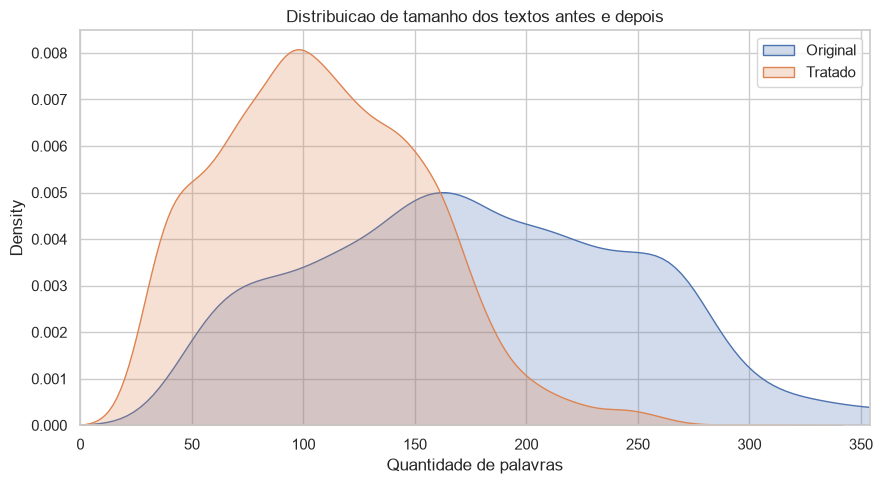

In [9]:
work_df["original_words"] = work_df["text_original"].str.split().str.len()
work_df["clean_words"] = work_df["text_clean"].str.split().str.len()

length_summary = work_df[["original_words", "clean_words"]].describe().round(2)
display(length_summary)

fig, ax = plt.subplots(figsize=(9, 5))
sns.kdeplot(data=work_df, x="original_words", label="Original", fill=True, alpha=0.25, ax=ax)
sns.kdeplot(data=work_df, x="clean_words", label="Tratado", fill=True, alpha=0.25, ax=ax)
ax.set_xlim(0, work_df["original_words"].quantile(0.98))
ax.set_title("Distribuicao de tamanho dos textos antes e depois")
ax.set_xlabel("Quantidade de palavras")
ax.legend()
plt.tight_layout()
length_plot_path = FIGURE_DIR / "text_length_before_after.png"
fig.savefig(length_plot_path, dpi=140, bbox_inches="tight")
plt.show()

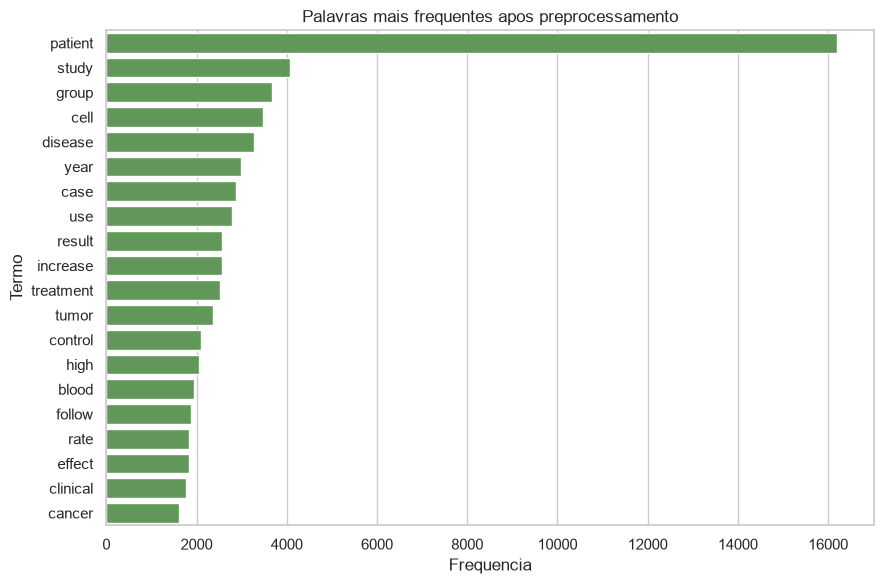

,termo,frequencia
0,patient,16207
1,study,4064
2,group,3679
3,cell,3474
4,disease,3276
5,year,2976
6,case,2869
7,use,2783
8,result,2569
9,increase,2557


In [10]:
top_terms = plot_top_terms(
    work_df["text_clean"],
    "Palavras mais frequentes apos preprocessamento",
    FIGURE_DIR / "top_terms_overall.png",
)
display(top_terms)

,classe,termo,frequencia
0,cardiovascular diseases,patient,3762
1,cardiovascular diseases,group,1168
2,cardiovascular diseases,pressure,1052
3,cardiovascular diseases,coronary,1008
4,cardiovascular diseases,study,987
5,cardiovascular diseases,artery,932
6,cardiovascular diseases,blood,929
7,cardiovascular diseases,ventricular,832
8,cardiovascular diseases,disease,821
9,cardiovascular diseases,increase,794


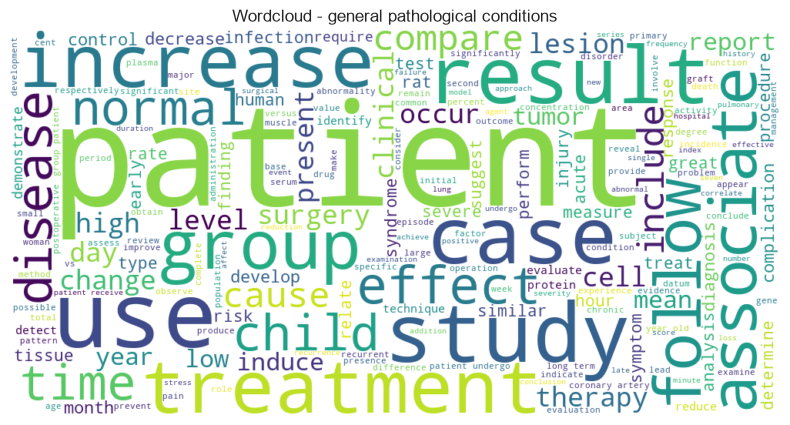

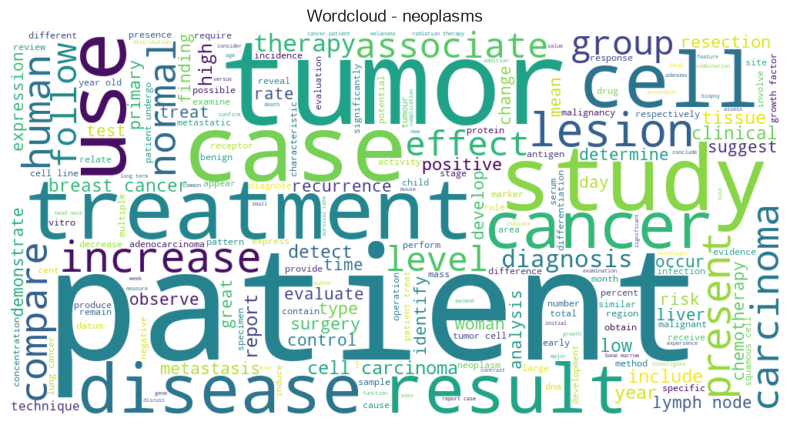

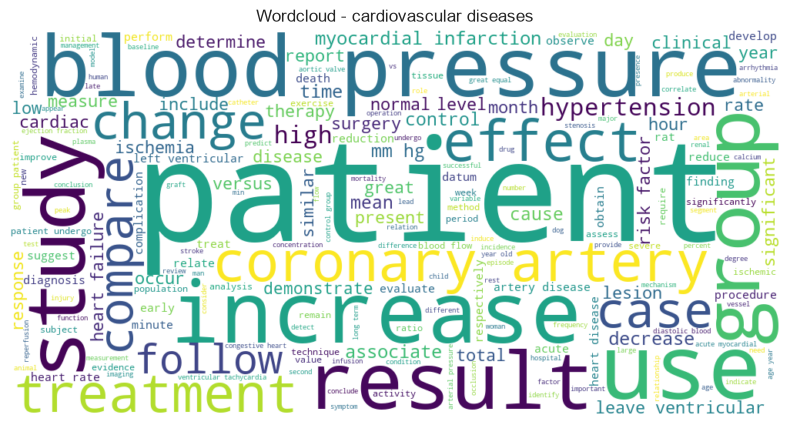

In [11]:
top_terms_by_class = []
for class_name, class_data in work_df.groupby(TARGET_COLUMN):
    counter = Counter(" ".join(class_data["text_clean"].dropna()).split())
    for term, frequency in counter.most_common(10):
        top_terms_by_class.append({"classe": class_name, "termo": term, "frequencia": frequency})

top_terms_by_class = pd.DataFrame(top_terms_by_class)
display(top_terms_by_class.head(30))

for class_name in work_df[TARGET_COLUMN].value_counts().head(3).index:
    class_slug = re.sub(r"[^a-z0-9]+", "_", class_name.lower()).strip("_")
    generate_wordcloud(
        work_df.loc[work_df[TARGET_COLUMN] == class_name, "text_clean"],
        f"Wordcloud - {class_name}",
        FIGURE_DIR / f"wordcloud_{class_slug}.png",
    )

## Separacao treino e teste

In [12]:
model_df = work_df.loc[work_df["text_clean"].str.strip().ne("")].copy()

X_train, X_test, y_train, y_test = train_test_split(
    model_df["text_clean"],
    model_df[TARGET_COLUMN],
    test_size=0.2,
    stratify=model_df[TARGET_COLUMN],
    random_state=RANDOM_STATE,
)

vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), min_df=2)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print(f"Treino: {X_train.shape[0]:,} registros")
print(f"Teste: {X_test.shape[0]:,} registros")
print(f"Matriz TF-IDF treino: {X_train_tfidf.shape}")
print("O TF-IDF foi ajustado apenas no treino para evitar vazamento de dados.")

Treino: 4,800 registros
Teste: 1,200 registros
Matriz TF-IDF treino: (4800, 5000)
O TF-IDF foi ajustado apenas no treino para evitar vazamento de dados.


## Modelagem baseline

C:\Users\jooar\ds\portfolio\ml3-f3-tech-challenge\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1457: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


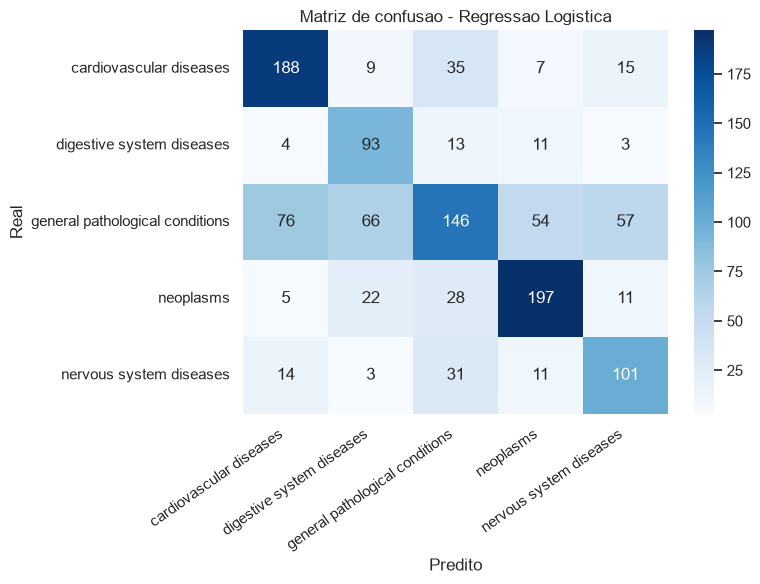

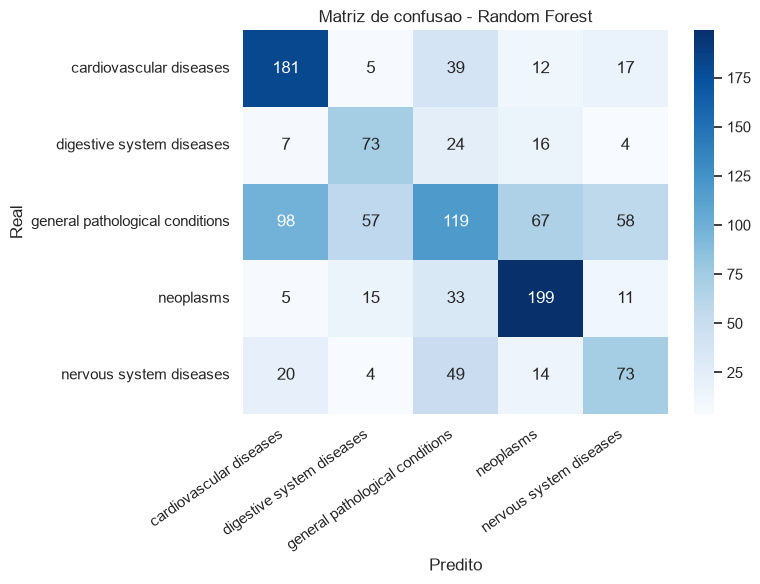

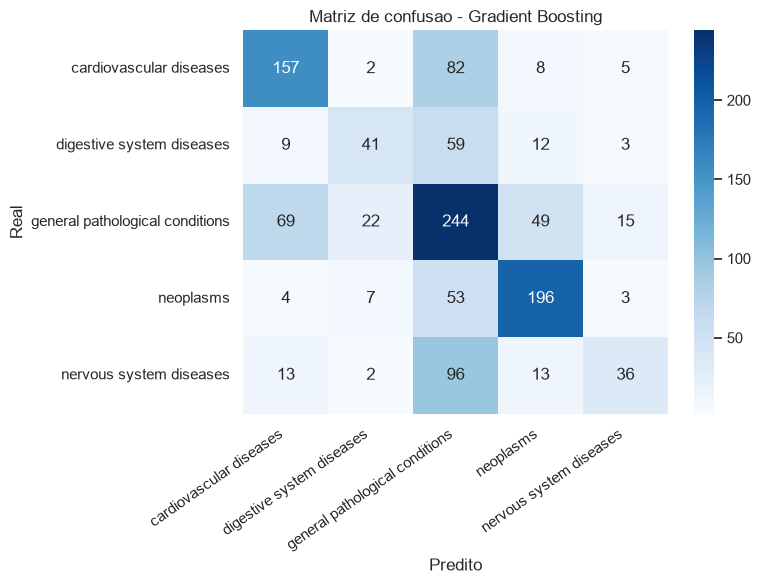

In [13]:
models = {
    "Regressao Logistica": LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        n_jobs=-1,
        random_state=RANDOM_STATE,
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=160,
        max_depth=None,
        class_weight="balanced",
        n_jobs=-1,
        random_state=RANDOM_STATE,
    ),
}

metric_rows = []
class_reports = {}
predictions = {}

for model_name, model in models.items():
    model.fit(X_train_tfidf, y_train)
    y_pred = model.predict(X_test_tfidf)
    predictions[model_name] = y_pred
    row, class_report = evaluate_model(model_name, y_test, y_pred)
    metric_rows.append(row)
    class_reports[model_name] = class_report
    plot_confusion(y_test, y_pred, f"Matriz de confusao - {model_name}", FIGURE_DIR / f"confusion_{model_name.lower().replace(' ', '_')}.png")

# Gradient Boosting nao e ideal para matrizes TF-IDF esparsas e amplas.
# Para viabilizar o comparativo exploratorio, aplicamos selecao chi2 e convertemos
# apenas as melhores features para matriz densa.
gb_k = min(800, X_train_tfidf.shape[1])
selector = SelectKBest(score_func=chi2, k=gb_k)
X_train_gb = selector.fit_transform(X_train_tfidf, y_train).toarray()
X_test_gb = selector.transform(X_test_tfidf).toarray()

gb_model = GradientBoostingClassifier(
    n_estimators=80,
    learning_rate=0.08,
    max_depth=3,
    random_state=RANDOM_STATE,
)
gb_model.fit(X_train_gb, y_train)
gb_pred = gb_model.predict(X_test_gb)
predictions["Gradient Boosting"] = gb_pred
row, class_report = evaluate_model("Gradient Boosting", y_test, gb_pred)
metric_rows.append(row)
class_reports["Gradient Boosting"] = class_report
plot_confusion(y_test, gb_pred, "Matriz de confusao - Gradient Boosting", FIGURE_DIR / "confusion_gradient_boosting.png")

## Avaliacao dos modelos

In [14]:
metrics_df = pd.DataFrame(metric_rows).sort_values("macro_f1", ascending=False).reset_index(drop=True)
metric_columns = [
    "weighted_precision",
    "weighted_recall",
    "weighted_f1",
    "macro_precision",
    "macro_recall",
    "macro_f1",
    "recall_medio_classes_minoritarias",
]
display(metrics_df.assign(**{col: metrics_df[col].round(4) for col in metric_columns}))

for model_name, report in class_reports.items():
    print(f"\nRecall/precision/f1 por classe - {model_name}")
    display(report[["precision", "recall", "f1-score", "support"]].round(4))

best_model = metrics_df.iloc[0]["modelo"]
print(f"Modelo baseline mais promissor neste split: {best_model}")
print("Mesmo quando metricas gerais forem altas, o recall por classe deve orientar a analise hospitalar.")

,modelo,weighted_precision,weighted_recall,weighted_f1,macro_precision,macro_recall,macro_f1,recall_medio_classes_minoritarias,observacao_classes_minoritarias
0,Regressao Logistica,0.6065,0.6042,0.5933,0.5915,0.6473,0.6075,0.6906,recall minoritario proximo da media ponderada no split avaliado
1,Random Forest,0.5234,0.5375,0.5223,0.5201,0.5625,0.5348,0.5225,acompanhar de perto; metrica ponderada pode mascarar desempenho
2,Gradient Boosting,0.5730,0.5617,0.5501,0.5839,0.5061,0.5213,0.2778,acompanhar de perto; metrica ponderada pode mascarar desempenho



Recall/precision/f1 por classe - Regressao Logistica


,precision,recall,f1-score,support
cardiovascular diseases,0.6551,0.7402,0.6950,254.0
digestive system diseases,0.4819,0.7500,0.5868,124.0
general pathological conditions,0.5771,0.3659,0.4479,399.0
neoplasms,0.7036,0.7490,0.7256,263.0
nervous system diseases,0.5401,0.6312,0.5821,160.0



Recall/precision/f1 por classe - Random Forest


,precision,recall,f1-score,support
cardiovascular diseases,0.5820,0.7126,0.6407,254.0
digestive system diseases,0.4740,0.5887,0.5252,124.0
general pathological conditions,0.4508,0.2982,0.3590,399.0
neoplasms,0.6461,0.7567,0.6970,263.0
nervous system diseases,0.4479,0.4562,0.4520,160.0



Recall/precision/f1 por classe - Gradient Boosting


,precision,recall,f1-score,support
cardiovascular diseases,0.6230,0.6181,0.6206,254.0
digestive system diseases,0.5541,0.3306,0.4141,124.0
general pathological conditions,0.4569,0.6115,0.5230,399.0
neoplasms,0.7050,0.7452,0.7246,263.0
nervous system diseases,0.5806,0.2250,0.3243,160.0


Modelo baseline mais promissor neste split: Regressao Logistica
Mesmo quando metricas gerais forem altas, o recall por classe deve orientar a analise hospitalar.


## Arquitetura teorica inicial para o MVP

In [15]:
architecture_steps = pd.DataFrame(
    [
        {"etapa": "Entrada", "descricao": "Texto medico digitado, enviado por formulario ou recebido por integracao."},
        {"etapa": "Preprocessamento", "descricao": "Normalizacao, limpeza leve, stopwords e lematizacao documentada."},
        {"etapa": "Vetorizacao", "descricao": "TF-IDF ajustado somente no conjunto de treino e persistido com o modelo."},
        {"etapa": "Classificador", "descricao": f"Baseline candidato: {best_model}, sujeito a validacao e comparacao futura."},
        {"etapa": "Saida", "descricao": "Classe prevista acompanhada de score/probabilidade quando o estimador permitir."},
        {"etapa": "Endpoint futuro", "descricao": "API REST para predicao em tempo real, com validacao de entrada e monitoramento."},
        {"etapa": "Refatoracao antes de producao", "descricao": "Separar pipeline, versionar artefatos, testar, monitorar drift e revisar riscos clinicos."},
    ]
)
display(architecture_steps)

,etapa,descricao
0,Entrada,"Texto medico digitado, enviado por formulario ou recebido por integracao."
1,Preprocessamento,"Normalizacao, limpeza leve, stopwords e lematizacao documentada."
2,Vetorizacao,TF-IDF ajustado somente no conjunto de treino e persistido com o modelo.
3,Classificador,"Baseline candidato: Regressao Logistica, sujeito a validacao e comparacao futura."
4,Saida,Classe prevista acompanhada de score/probabilidade quando o estimador permitir.
5,Endpoint futuro,"API REST para predicao em tempo real, com validacao de entrada e monitoramento."
6,Refatoracao antes de producao,"Separar pipeline, versionar artefatos, testar, monitorar drift e revisar riscos clinicos."


## Principais achados

In [16]:
minority_class = class_distribution.sort_values("registros").iloc[0]["classe"]
largest_class = class_distribution.sort_values("registros", ascending=False).iloc[0]["classe"]

findings = [
    f"A base consolidada possui {len(df):,} registros e {df[TARGET_COLUMN].nunique()} classes.",
    f"A maior classe e '{largest_class}' e a menor classe e '{minority_class}', indicando necessidade de acompanhar desbalanceamento.",
    "O preprocessamento reduziu ruido superficial, mas numeros foram preservados por poderem conter informacao clinica.",
    f"O melhor baseline neste experimento foi {best_model}, considerando macro-F1 como criterio principal.",
    "Random Forest e Gradient Boosting foram mantidos como comparativos exploratorios; eles tendem a ser menos naturais para TF-IDF esparso.",
    "A analise usa abstracts medicos publicos do Kaggle como proxy academico, nao dados operacionais de hospital nem validacao clinica.",
]

for item in findings:
    print(f"- {item}")

- A base consolidada possui 14,438 registros e 5 classes.
- A maior classe e 'general pathological conditions' e a menor classe e 'digestive system diseases', indicando necessidade de acompanhar desbalanceamento.
- O preprocessamento reduziu ruido superficial, mas numeros foram preservados por poderem conter informacao clinica.
- O melhor baseline neste experimento foi Regressao Logistica, considerando macro-F1 como criterio principal.
- Random Forest e Gradient Boosting foram mantidos como comparativos exploratorios; eles tendem a ser menos naturais para TF-IDF esparso.
- A analise usa abstracts medicos publicos do Kaggle como proxy academico, nao dados operacionais de hospital nem validacao clinica.


## Relatorio de EDA em HTML

In [17]:
def image_tag(path: Path, alt: str) -> str:
    """Return an HTML image tag when the image exists."""
    if not path.exists():
        return f"<p><em>Figura nao encontrada: {escape(str(path))}</em></p>"
    relative = path.relative_to(REPORT_DIR).as_posix()
    return f'<figure><img src="{escape(relative)}" alt="{escape(alt)}"><figcaption>{escape(alt)}</figcaption></figure>'


library_versions = pd.DataFrame(
    [
        {"biblioteca": "python", "versao": "3.11"},
        {"biblioteca": "pandas", "versao": pd.__version__},
        {"biblioteca": "numpy", "versao": np.__version__},
        {"biblioteca": "scikit-learn", "versao": sklearn.__version__},
        {"biblioteca": "matplotlib", "versao": matplotlib.__version__},
        {"biblioteca": "seaborn", "versao": sns.__version__},
        {"biblioteca": "nltk", "versao": nltk.__version__},
        {"biblioteca": "spaCy", "versao": spacy.__version__},
        {"biblioteca": "spaCy model", "versao": spacy_model_used},
    ]
)

production_candidates = pd.DataFrame(
    [
        {"biblioteca": "pandas", "uso": "ingestao offline e auditoria de dados"},
        {"biblioteca": "scikit-learn", "uso": "pipeline TF-IDF + classificador baseline"},
        {"biblioteca": "joblib", "uso": "persistencia do pipeline treinado"},
        {"biblioteca": "FastAPI", "uso": "endpoint futuro de predicao"},
        {"biblioteca": "prometheus-client", "uso": "metricas de API em producao"},
        {"biblioteca": "onnxruntime", "uso": "candidato para reduzir latencia do classificador"},
    ]
)

wordcloud_html = "\\n".join(
    image_tag(path, f"Wordcloud - {path.stem.replace('wordcloud_', '').replace('_', ' ')}")
    for path in sorted(FIGURE_DIR.glob("wordcloud_*.png"))
)
confusion_html = "\\n".join(
    image_tag(path, f"Matriz de confusao - {path.stem.replace('confusion_', '').replace('_', ' ')}")
    for path in sorted(FIGURE_DIR.glob("confusion_*.png"))
)

html = f"""
<!doctype html>
<html lang="pt-BR">
<head>
  <meta charset="utf-8">
  <title>Relatorio EDA NLP Hospitalar</title>
  <style>
    body {{ font-family: Arial, sans-serif; line-height: 1.5; margin: 40px; color: #222; }}
    h1, h2 {{ color: #1f4e79; }}
    table {{ border-collapse: collapse; width: 100%; margin: 16px 0; }}
    th, td {{ border: 1px solid #ddd; padding: 8px; text-align: left; }}
    th {{ background: #f2f5f7; }}
    img {{ max-width: 100%; height: auto; border: 1px solid #ddd; }}
    figure {{ margin: 20px 0; }}
    figcaption {{ font-size: 0.9em; color: #555; }}
    .note {{ background: #fff8e1; padding: 12px; border-left: 4px solid #d39e00; }}
  </style>
</head>
<body>
  <h1>Relatorio de EDA e baseline para classificacao de textos hospitalares</h1>
  <p class="note">Este relatorio e exploratorio. O dataset vem de abstracts medicos publicos do Kaggle e deve ser tratado como proxy academico, nao validacao clinica.</p>

  <h2>1. Contexto do dataset</h2>
  <p>Origem: Medical Abstracts TC Corpus no Kaggle. A base contem abstracts medicos rotulados por area/doenca.</p>
  {class_distribution.to_html(index=False)}
  {image_tag(class_plot_path, "Distribuicao das classes")}

  <h2>2. Problema de classificacao</h2>
  <p>O problema foi modelado como classificacao multiclasse, onde cada texto possui uma unica classe associada.</p>

  <h2>3. Preparacao dos dados</h2>
  <p>Foram aplicadas normalizacao, conversao para minusculas, limpeza de pontuacao, remocao de stopwords via NLTK e lematizacao com spaCy. Numeros foram preservados por poderem carregar informacao clinica.</p>
  {length_summary.to_html()}
  {image_tag(length_plot_path, "Distribuicao de tamanho antes e depois do preprocessamento")}

  <h2>4. Graficos e principais insights</h2>
  {image_tag(FIGURE_DIR / "top_terms_overall.png", "Palavras mais frequentes apos preprocessamento")}
  {top_terms.head(20).to_html(index=False)}
  {wordcloud_html}

  <h2>5. Comparacao entre arquiteturas baseline</h2>
  {metrics_df.to_html(index=False, float_format=lambda value: f"{value:.4f}" if isinstance(value, float) else str(value))}
  {confusion_html}

  <h2>6. Modelo baseline mais promissor</h2>
  <p>Modelo candidato neste split: <strong>{escape(str(best_model))}</strong>. A justificativa considera macro-F1 e macro-recall para reduzir o risco de metricas ponderadas esconderem desempenho ruim em classes menores.</p>

  <h2>7. Sugestoes de refatoracao para pipeline futuro</h2>
  {architecture_steps.to_html(index=False)}

  <h2>8. Bibliotecas usadas no desenvolvimento</h2>
  {library_versions.to_html(index=False)}

  <h2>9. Bibliotecas candidatas para producao</h2>
  {production_candidates.to_html(index=False)}

  <h2>10. Privacidade e dados sensiveis</h2>
  <p>O notebook evita exibir textos completos em massa e usa exemplos truncados. Em dados reais de hospital, seria necessario aplicar mascaramento de informacoes sensiveis, controle de acesso, revisao juridica e validacao clinica antes de qualquer uso operacional.</p>

  <h2>Limitacoes</h2>
  <ul>
    <li>Amostra de trabalho limitada a {WORKING_SAMPLE_SIZE:,} registros para manter a execucao local viavel.</li>
    <li>Dataset em ingles e baseado em abstracts, nao em fluxo real de triagem hospitalar.</li>
    <li>Gradient Boosting exigiu selecao de features e conversao densa por limitacao com matriz TF-IDF esparsa.</li>
    <li>Resultados devem orientar proximas decisoes, nao encerrar a escolha da arquitetura.</li>
  </ul>
</body>
</html>
"""

REPORT_PATH.write_text(html, encoding="utf-8")
print(f"Relatorio salvo em: {REPORT_PATH}")

Relatorio salvo em: C:\Users\jooar\ds\portfolio\ml3-f3-tech-challenge\reports\eda_nlp_hospital_baseline.html
